In [109]:
import torch
from pathlib import Path
from models import SmallCnn
from utils import run_one_epoch,set_seed,evaluate_model,calculate_classification_metrics,plot_confusion_matrices
from datasets import val_loader
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [110]:
# ==============================================
# use the best model we saved and get metrics.
# ==============================================
set_seed(42)
model_best = SmallCnn(
    num_classes=8,
    dropout=0
).to(device)
state_dict = torch.load("../results/saved/best_baseline_small_cnn_0.0.pt")
model_best.load_state_dict(state_dict)
model_best.eval()
best_val_metrics = run_one_epoch(
    model_best,
    val_loader,
    optimizer=None,
    device=device
)
print(best_val_metrics)

# Epoch 46/50
# Train Accuracy: 99.7%
# Val Accuracy:   83.2%
# Val Loss:       0.651


{'loss': 0.6509968135171308, 'Accuracy': 0.8323353293413174}


In [111]:
y_true_base, y_pred_base = evaluate_model(
    model_best,
    val_loader,
    device=device
)

print(len(y_true_base))
print(len(y_pred_base))
print(y_true_base[:10])
print(y_pred_base[:10])

167
167
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 7, 0, 0, 0, 0, 7, 0, 0]


In [112]:
classes = ['ambulance','autobus','kamyun','kamyunet','minibus','savari','taxi','vanet']

metrics_base = calculate_classification_metrics(y_true_base, y_pred_base)


print(f"Precision macro: {metrics_base['precision_macro']:.4f}")
print(f"Recall macro: {metrics_base['recall_macro']:.4f}")
print(f"F1 macro: {metrics_base['f1_macro']:.4f}")

print("\nPer-class metrics:")

for class_name, precision, recall, f1 in zip(
    classes,
    metrics_base['per_class_precision'],
    metrics_base['per_class_recall'],
    metrics_base['per_class_f1']
):
    print(
        f"{class_name:10s} | "
        f"Precision: {precision:.2f} | "
        f"Recall: {recall:.2f} | "
        f"F1: {f1:.2f}"
    )

Precision macro: 0.8561
Recall macro: 0.8365
F1 macro: 0.8403

Per-class metrics:
ambulance  | Precision: 1.00 | Recall: 0.83 | F1: 0.91
autobus    | Precision: 0.86 | Recall: 0.90 | F1: 0.88
kamyun     | Precision: 0.93 | Recall: 0.65 | F1: 0.76
kamyunet   | Precision: 0.94 | Recall: 0.84 | F1: 0.89
minibus    | Precision: 0.82 | Recall: 0.90 | F1: 0.86
savari     | Precision: 0.68 | Recall: 0.85 | F1: 0.76
taxi       | Precision: 0.90 | Recall: 0.95 | F1: 0.93
vanet      | Precision: 0.72 | Recall: 0.77 | F1: 0.74


In [113]:
cm_base = confusion_matrix(y_true_base,y_pred_base)
print(cm_base)
cm_base.shape

[[15  0  0  0  0  0  0  3]
 [ 0 18  0  0  1  0  1  0]
 [ 0  2 13  1  2  0  0  2]
 [ 0  1  1 16  0  0  0  1]
 [ 0  0  0  0 18  1  0  1]
 [ 0  0  0  0  0 17  1  2]
 [ 0  0  0  0  0  1 19  0]
 [ 0  0  0  0  1  6  0 23]]


(8, 8)

In [114]:
cm_normalized_base = cm_base / cm_base.sum(axis=1, keepdims=True)
print(cm_normalized_base)
# قطر اصلی ماتریس همان recall هر کلاس است

[[0.83333333 0.         0.         0.         0.         0.
  0.         0.16666667]
 [0.         0.9        0.         0.         0.05       0.
  0.05       0.        ]
 [0.         0.1        0.65       0.05       0.1        0.
  0.         0.1       ]
 [0.         0.05263158 0.05263158 0.84210526 0.         0.
  0.         0.05263158]
 [0.         0.         0.         0.         0.9        0.05
  0.         0.05      ]
 [0.         0.         0.         0.         0.         0.85
  0.05       0.1       ]
 [0.         0.         0.         0.         0.         0.05
  0.95       0.        ]
 [0.         0.         0.         0.         0.03333333 0.2
  0.         0.76666667]]


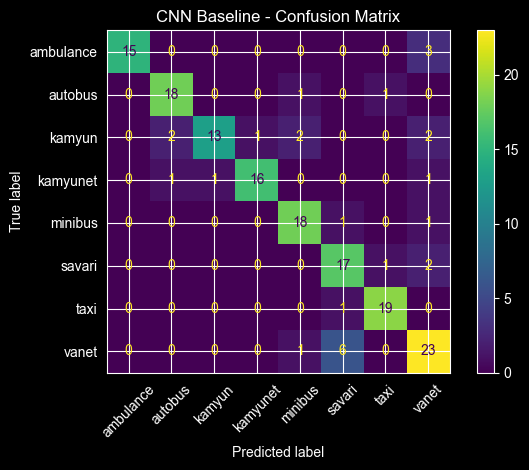

In [115]:
output_dir = Path("../results/img")
output_dir.mkdir(parents=True, exist_ok=True)

cmd = ConfusionMatrixDisplay(
    confusion_matrix=cm_base,
    display_labels=classes
)
cmd.plot(xticks_rotation=45)
plt.title("CNN Baseline - Confusion Matrix")
plt.tight_layout()
plt.savefig(
    output_dir / "SmallCnn_base_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

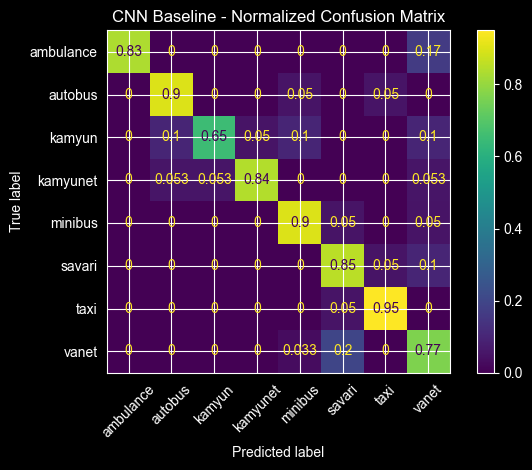

In [116]:
cmd = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized_base,
    display_labels=classes
)
cmd.plot(xticks_rotation=45)
plt.title("CNN Baseline - Normalized Confusion Matrix")
plt.tight_layout()
plt.savefig(
    output_dir / "SmallCnn_base_confusion_matrix_normalized.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

SmallCnn Augmented

In [117]:
model_aug_best = SmallCnn(
    num_classes=8,
    dropout=0
).to(device)

state_dict = torch.load(
    "../results/saved/best_augmented_small_cnn.pt",
    map_location=device
)

model_aug_best.load_state_dict(state_dict)

<All keys matched successfully>

In [118]:
y_true_aug, y_pred_aug = evaluate_model(
    model_aug_best,
    val_loader,
    device=device
)

In [119]:
metrics_aug = calculate_classification_metrics(y_true_aug, y_pred_aug)

print(f"Precision macro: {metrics_aug['precision_macro']:.4f}")
print(f"Recall macro: {metrics_aug['recall_macro']:.4f}")
print(f"F1 macro: {metrics_aug['f1_macro']:.4f}")

print("\nPer-class metrics:")

for class_name, precision, recall, f1 in zip(
    classes,
    metrics_aug['per_class_precision'],
    metrics_aug['per_class_recall'],
    metrics_aug['per_class_f1']
):
    print(
        f"{class_name:10s} | "
        f"Precision: {precision:.2f} | "
        f"Recall: {recall:.2f} | "
        f"F1: {f1:.2f}"
    )

Precision macro: 0.8207
Recall macro: 0.8185
F1 macro: 0.8128

Per-class metrics:
ambulance  | Precision: 0.76 | Recall: 0.89 | F1: 0.82
autobus    | Precision: 1.00 | Recall: 0.75 | F1: 0.86
kamyun     | Precision: 0.89 | Recall: 0.80 | F1: 0.84
kamyunet   | Precision: 0.73 | Recall: 0.84 | F1: 0.78
minibus    | Precision: 0.73 | Recall: 0.95 | F1: 0.83
savari     | Precision: 0.82 | Recall: 0.70 | F1: 0.76
taxi       | Precision: 0.86 | Recall: 0.95 | F1: 0.90
vanet      | Precision: 0.77 | Recall: 0.67 | F1: 0.71


In [120]:
cm_aug = confusion_matrix(y_true_aug,y_pred_aug)
print(cm_aug)
cm_aug.shape

[[16  0  0  1  0  0  0  1]
 [ 1 15  0  1  2  0  1  0]
 [ 0  0 16  3  1  0  0  0]
 [ 0  0  1 16  2  0  0  0]
 [ 0  0  0  0 19  0  0  1]
 [ 1  0  0  0  1 14  0  4]
 [ 0  0  0  0  0  1 19  0]
 [ 3  0  1  1  1  2  2 20]]


(8, 8)

In [121]:
cm_normalized_aug = cm_aug / cm_aug.sum(axis=1, keepdims=True)
print(cm_normalized_aug)


[[0.88888889 0.         0.         0.05555556 0.         0.
  0.         0.05555556]
 [0.05       0.75       0.         0.05       0.1        0.
  0.05       0.        ]
 [0.         0.         0.8        0.15       0.05       0.
  0.         0.        ]
 [0.         0.         0.05263158 0.84210526 0.10526316 0.
  0.         0.        ]
 [0.         0.         0.         0.         0.95       0.
  0.         0.05      ]
 [0.05       0.         0.         0.         0.05       0.7
  0.         0.2       ]
 [0.         0.         0.         0.         0.         0.05
  0.95       0.        ]
 [0.1        0.         0.03333333 0.03333333 0.03333333 0.06666667
  0.06666667 0.66666667]]


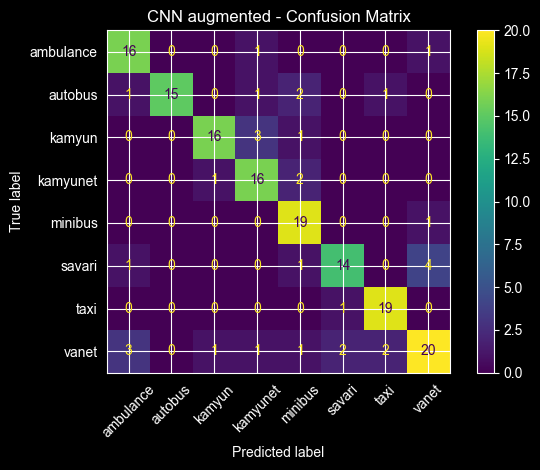

In [122]:
output_dir = Path("../results/img")
output_dir.mkdir(parents=True, exist_ok=True)

cmd = ConfusionMatrixDisplay(
    confusion_matrix=cm_aug,
    display_labels=classes
)
cmd.plot(xticks_rotation=45)
plt.title("CNN augmented - Confusion Matrix")
plt.tight_layout()
plt.savefig(
    output_dir / "SmallCnn_aug_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

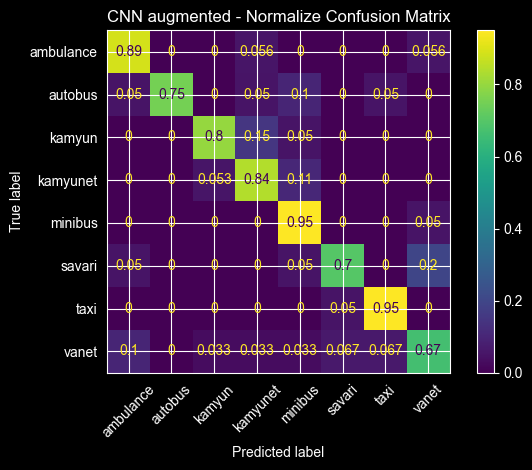

In [123]:
output_dir = Path("../results/img")
output_dir.mkdir(parents=True, exist_ok=True)

cmd = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized_aug,
    display_labels=classes
)
cmd.plot(xticks_rotation=45)
plt.title("CNN augmented - Normalize Confusion Matrix")
plt.tight_layout()
plt.savefig(
    output_dir / "SmallCnn_aug_confusion_matrix_normalized.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()


### small cnn with dropout [0.3, 0.5]


In [124]:
def evaluate_checkpoint(checkpoint_path, dropout, val_loader, device):
    model = SmallCnn(
        num_classes=8,
        dropout=dropout
    ).to(device)
    state_dict = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state_dict)

    y_true , y_pred = evaluate_model(
        model,
        val_loader,
        device=device
    )
    cm_drop, cm_normalized_drop = plot_confusion_matrices(
    y_true=y_true,
    y_pred=y_pred,
    classes=classes,
    experiment_name=f"small_cnn_dropout_{dropout}",
    output_dir="../results/img"
)
    metrics = calculate_classification_metrics(y_true,y_pred)

    return metrics,cm_drop,cm_normalized_drop

In [125]:
checkpoint_dir = Path("../results/saved")

dropout_experiments = {
    "dropout_0.0": {
        "dropout": 0.0,
        "checkpoint": checkpoint_dir / "best_baseline_small_cnn_0.0.pt"
    },
    "dropout_0.3": {
        "dropout": 0.3,
        "checkpoint": checkpoint_dir / "best_baseline_small_cnn_0.3.pt"
    },
    "dropout_0.5": {
        "dropout": 0.5,
        "checkpoint": checkpoint_dir / "best_baseline_small_cnn_0.5.pt"
    }
}

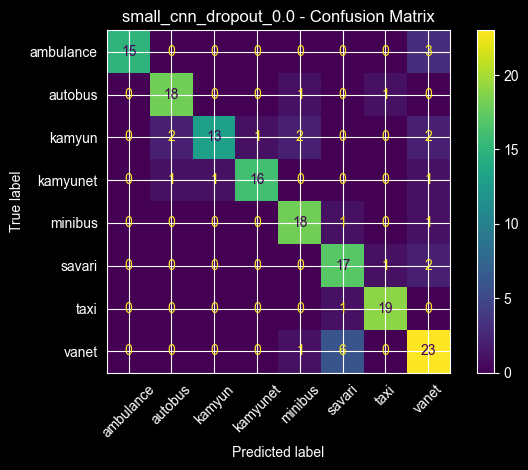

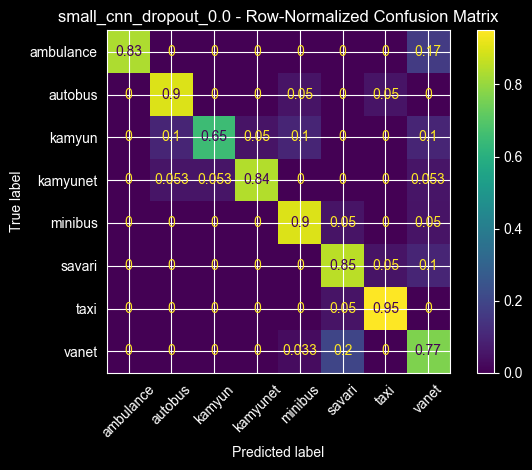

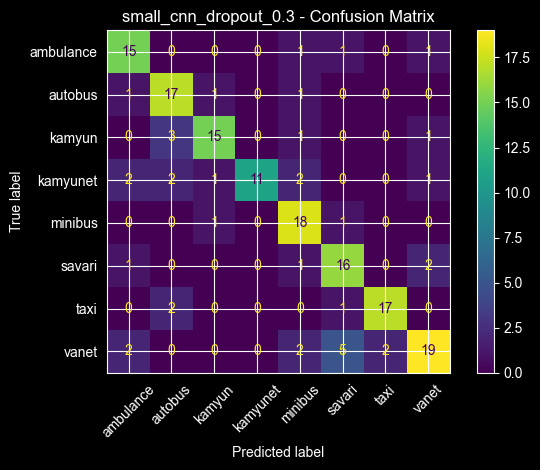

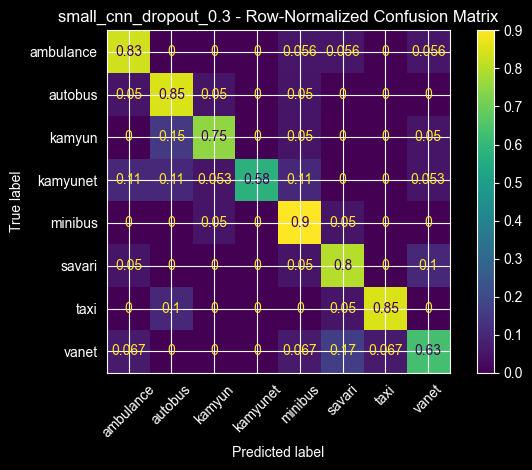

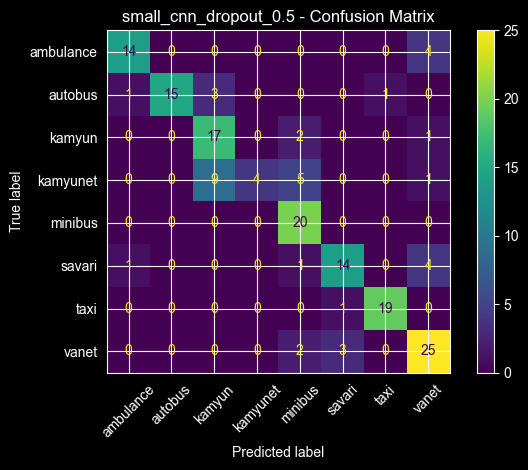

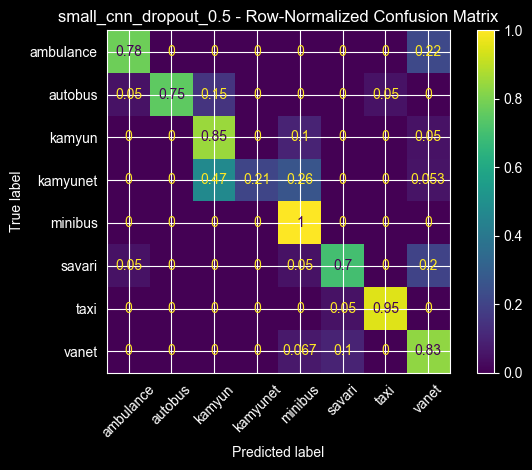

In [126]:
dropout_metrics = {}
cm_drop_dict = {}
for name, config in dropout_experiments.items():

    metrics,cm_drop,cm_normalized_drop = evaluate_checkpoint(
        checkpoint_path=config["checkpoint"],
        dropout=config["dropout"],
        val_loader=val_loader,
        device=device
    )

    dropout_metrics[name] = metrics
    cm_drop_dict[name] = [cm_drop,cm_normalized_drop]

In [127]:
print("\n=== Dropout Comparison ===")

print(
    f"{'Dropout':<10}"
    f"{'Precision':<12}"
    f"{'Recall':<12}"
    f"{'F1':<12}"
)

for name, metrics in dropout_metrics.items():

    dropout = name.replace("dropout_", "")

    print(
        f"{dropout:<10}"
        f"{metrics['precision_macro']:<12.4f}"
        f"{metrics['recall_macro']:<12.4f}"
        f"{metrics['f1_macro']:<12.5f}"
    )


=== Dropout Comparison ===
Dropout   Precision   Recall      F1          
0.0       0.8561      0.8365      0.84027     
0.3       0.7877      0.7745      0.76877     
0.5       0.8212      0.7590      0.74731     


In [128]:
for name, metrics in dropout_metrics.items():

    print(f"\n=== {name} - Per Class ===")

    for class_name, precision, recall, f1 in zip(
        classes,
        metrics["per_class_precision"],
        metrics["per_class_recall"],
        metrics["per_class_f1"]
    ):
        print(
            f"{class_name:10s} | "
            f"Precision: {precision:.2f} | "
            f"Recall: {recall:.2f} | "
            f"F1: {f1:.2f}"
        )


=== dropout_0.0 - Per Class ===
ambulance  | Precision: 1.00 | Recall: 0.83 | F1: 0.91
autobus    | Precision: 0.86 | Recall: 0.90 | F1: 0.88
kamyun     | Precision: 0.93 | Recall: 0.65 | F1: 0.76
kamyunet   | Precision: 0.94 | Recall: 0.84 | F1: 0.89
minibus    | Precision: 0.82 | Recall: 0.90 | F1: 0.86
savari     | Precision: 0.68 | Recall: 0.85 | F1: 0.76
taxi       | Precision: 0.90 | Recall: 0.95 | F1: 0.93
vanet      | Precision: 0.72 | Recall: 0.77 | F1: 0.74

=== dropout_0.3 - Per Class ===
ambulance  | Precision: 0.71 | Recall: 0.83 | F1: 0.77
autobus    | Precision: 0.71 | Recall: 0.85 | F1: 0.77
kamyun     | Precision: 0.83 | Recall: 0.75 | F1: 0.79
kamyunet   | Precision: 1.00 | Recall: 0.58 | F1: 0.73
minibus    | Precision: 0.69 | Recall: 0.90 | F1: 0.78
savari     | Precision: 0.67 | Recall: 0.80 | F1: 0.73
taxi       | Precision: 0.89 | Recall: 0.85 | F1: 0.87
vanet      | Precision: 0.79 | Recall: 0.63 | F1: 0.70

=== dropout_0.5 - Per Class ===
ambulance  | Precisio

### avgpool

In [129]:
model_avg_best = SmallCnn(
    num_classes=8,
    dropout=0.0,
    pooling="avg"
).to(device)

state_dict = torch.load(
    "../results/saved/best_small_cnn_avg_pool.pt",
    map_location=device
)

model_avg_best.load_state_dict(state_dict)
model_avg_best

SmallCnn(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): 

In [130]:
model_avg_best.eval()
best_avg_metrics = run_one_epoch(
    model_avg_best,
    val_loader,
    optimizer=None,
    device=device
)
print(best_avg_metrics)


{'loss': 0.6550427589587823, 'Accuracy': 0.7844311377245509}


In [131]:
y_true_avg, y_pred_avg = evaluate_model(
    model_avg_best,
    val_loader,
    device=device
)
avg_metrics = calculate_classification_metrics(
    y_true=y_true_avg,
    y_pred=y_pred_avg,
)


In [132]:
print(f"Precision macro: {avg_metrics['precision_macro']:.4f}")
print(f"Recall macro: {avg_metrics['recall_macro']:.4f}")
print(f"F1 macro: {avg_metrics['f1_macro']:.4f}")

print("\nPer-class metrics:")

for class_name, precision, recall, f1 in zip(
    classes,
    avg_metrics['per_class_precision'],
    avg_metrics['per_class_recall'],
    avg_metrics['per_class_f1']
):
    print(
        f"{class_name:10s} | "
        f"Precision: {precision:.2f} | "
        f"Recall: {recall:.2f} | "
        f"F1: {f1:.2f}"
    )

Precision macro: 0.8056
Recall macro: 0.7845
F1 macro: 0.7851

Per-class metrics:
ambulance  | Precision: 0.78 | Recall: 0.78 | F1: 0.78
autobus    | Precision: 0.62 | Recall: 0.90 | F1: 0.73
kamyun     | Precision: 0.68 | Recall: 0.65 | F1: 0.67
kamyunet   | Precision: 1.00 | Recall: 0.63 | F1: 0.77
minibus    | Precision: 0.86 | Recall: 0.90 | F1: 0.88
savari     | Precision: 0.88 | Recall: 0.70 | F1: 0.78
taxi       | Precision: 0.86 | Recall: 0.95 | F1: 0.90
vanet      | Precision: 0.77 | Recall: 0.77 | F1: 0.77


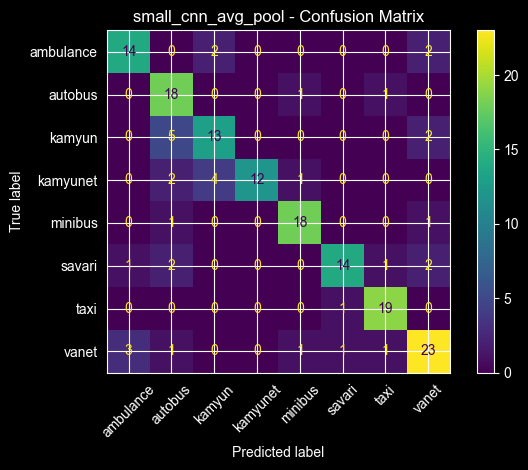

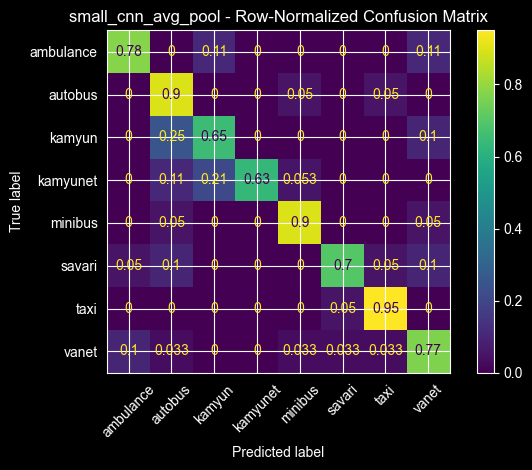

In [133]:
cm_avg, cm_normalized_avg = plot_confusion_matrices(
    y_true=y_true_avg,
    y_pred=y_pred_avg,
    classes=classes,
    experiment_name="small_cnn_avg_pool",
    output_dir="../results/img"
)

### weight decay

In [134]:
model_weight_decay_best = SmallCnn(
    num_classes=8,
    dropout=0,
    pooling="max"
).to(device)

state_dict = torch.load(
    "../results/saved/best_weight_decay_small_cnn_0.0001.pt",
    map_location=device
)

model_weight_decay_best.load_state_dict(state_dict)


model_weight_decay_best.eval()
best_weight_decay_metrics = run_one_epoch(
    model_weight_decay_best,
    val_loader,
    optimizer=None,
    device=device
)
print(best_weight_decay_metrics)

{'loss': 0.7125278136687364, 'Accuracy': 0.8203592814371258}


In [135]:
y_true_wd , y_pred_wd = evaluate_model(
    model_weight_decay_best,
    val_loader,
    device=device
)
len(y_true_wd)

167

In [136]:
wd_metrics = calculate_classification_metrics(
    y_true_wd,
    y_pred_wd
)
print(f"Precision macro: {wd_metrics['precision_macro']:.4f}")
print(f"Recall macro: {wd_metrics['recall_macro']:.4f}")
print(f"F1 macro: {wd_metrics['f1_macro']:.4f}")

for classs,precision, recall,f1 in zip(
    classes,
    wd_metrics['per_class_precision'],
    wd_metrics['per_class_recall'],
    wd_metrics['per_class_f1']
):
    print(
        f"{classs:10s} | "
        f"Precision: {precision:.2f} | "
        f"Recall: {recall:.2f} | "
        f"F1: {f1:.2f}"
    )

Precision macro: 0.8433
Recall macro: 0.8234
F1 macro: 0.8283
ambulance  | Precision: 1.00 | Recall: 0.83 | F1: 0.91
autobus    | Precision: 0.86 | Recall: 0.90 | F1: 0.88
kamyun     | Precision: 0.88 | Recall: 0.70 | F1: 0.78
kamyunet   | Precision: 0.93 | Recall: 0.74 | F1: 0.82
minibus    | Precision: 0.82 | Recall: 0.90 | F1: 0.86
savari     | Precision: 0.71 | Recall: 0.85 | F1: 0.77
taxi       | Precision: 0.86 | Recall: 0.90 | F1: 0.88
vanet      | Precision: 0.70 | Recall: 0.77 | F1: 0.73


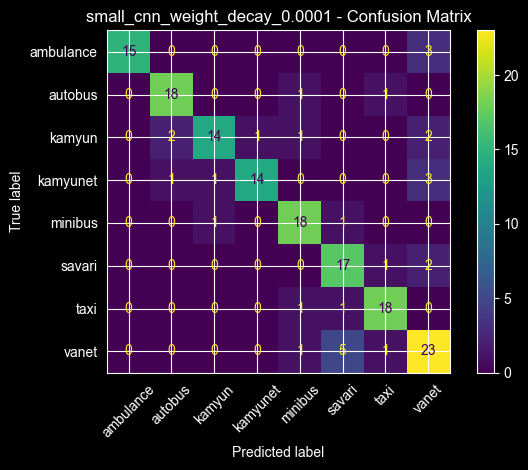

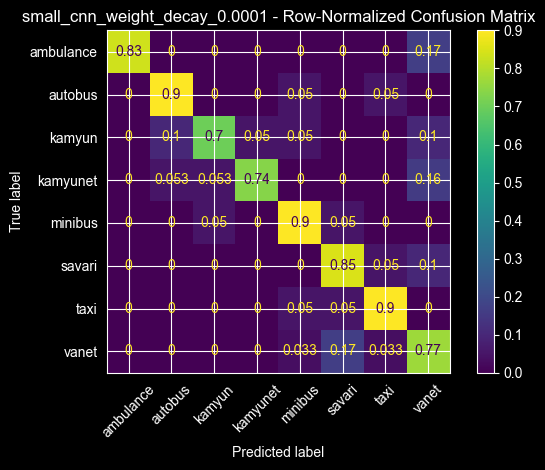

In [137]:
cm_wd, cm_normalized_wd = plot_confusion_matrices(
    y_true=y_true_wd,
    y_pred=y_pred_wd,
    classes=classes,
    experiment_name="small_cnn_weight_decay_0.0001",
    output_dir="../results/img"
)

#### StepLR

In [138]:
model_lr = SmallCnn(
    num_classes=8,
    dropout=0,
    pooling="max"
).to(device)
state_dict = torch.load("../results/saved/best_small_cnn_step_lr.pt")
model_lr.load_state_dict(state_dict)
model_lr.eval()
best_lr_metrics = run_one_epoch(
    model_lr,
    val_loader,
    device=device
)
print(best_lr_metrics)

{'loss': 0.9407647633980848, 'Accuracy': 0.7005988023952096}


In [139]:
y_true_lr, y_pred_lr = evaluate_model(
    model_lr,
    val_loader,
    device=device
)
len(y_true_lr)

167

In [140]:
lr_metrics = calculate_classification_metrics(
    y_true_lr,
    y_pred_lr
)
print(f"Precision macro: {lr_metrics['precision_macro']:.4f}")
print(f"Recall macro: {lr_metrics['recall_macro']:.4f}")
print(f"F1 macro: {lr_metrics['f1_macro']:.4f}")

for cls,precision, recall,f1 in zip(
    classes,
    lr_metrics['per_class_precision'],
    lr_metrics['per_class_recall'],
    lr_metrics['per_class_f1']
):
    print(
        f"{cls:10s} | "
        f"Precision: {precision:.2f} | "
        f"Recall: {recall:.2f} | "
        f"F1: {f1:.2f}"
    )

Precision macro: 0.6991
Recall macro: 0.7081
F1 macro: 0.6991
ambulance  | Precision: 0.74 | Recall: 0.78 | F1: 0.76
autobus    | Precision: 0.68 | Recall: 0.65 | F1: 0.67
kamyun     | Precision: 0.60 | Recall: 0.45 | F1: 0.51
kamyunet   | Precision: 0.67 | Recall: 0.74 | F1: 0.70
minibus    | Precision: 0.71 | Recall: 0.75 | F1: 0.73
savari     | Precision: 0.58 | Recall: 0.75 | F1: 0.65
taxi       | Precision: 0.86 | Recall: 0.95 | F1: 0.90
vanet      | Precision: 0.75 | Recall: 0.60 | F1: 0.67


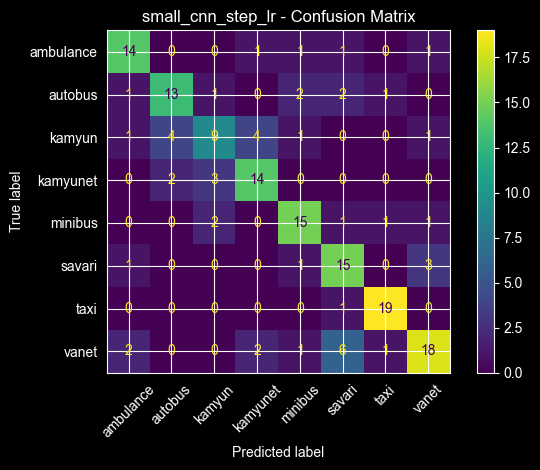

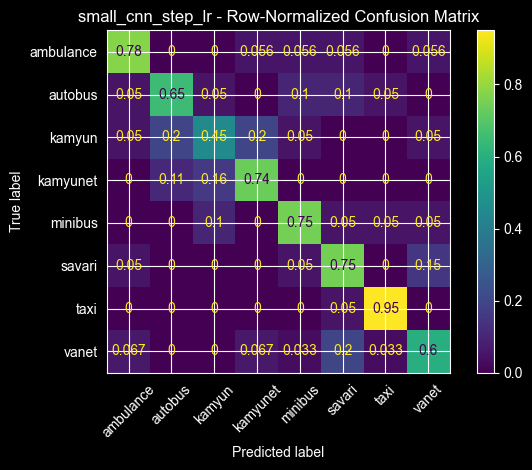

In [141]:
cm_lr, cm_normalized_lr = plot_confusion_matrices(
    y_true=y_true_lr,
    y_pred=y_pred_lr,
    classes=classes,
    experiment_name="small_cnn_step_lr",
    output_dir="../results/img"
)

### ReduceLROnPlateau

In [143]:
model_lrp = SmallCnn(
    num_classes=8,
    dropout=0,
    pooling="max",
).to(device)
state_dict = torch.load("../results/saved/best_reduce_lr_small_cnn.pt")
model_lrp.load_state_dict(state_dict)
model_lrp.eval()
best_lrp_metrics = run_one_epoch(
    model_lrp,
    val_loader,
    device=device,
)
best_lrp_metrics

{'loss': 0.7095450120057888, 'Accuracy': 0.7724550898203593}

In [144]:
y_true_rlr, y_pred_rlr = evaluate_model(
    model_lrp,
    val_loader,
    device=device
)
len(y_true_rlr)

167

In [145]:
rlr_metrics = calculate_classification_metrics(
    y_true_rlr,
    y_pred_rlr
)
print(f"Precision macro: {rlr_metrics['precision_macro']:.4f}")
print(f"Recall macro: {rlr_metrics['recall_macro']:.4f}")
print(f"F1 macro: {rlr_metrics['f1_macro']:.4f}")

for cls,precision, recall,f1 in zip(
    classes,
    rlr_metrics['per_class_precision'],
    rlr_metrics['per_class_recall'],
    rlr_metrics['per_class_f1']
):
    print(
        f"{cls:10s} | "
        f"Precision: {precision:.2f} | "
        f"Recall: {recall:.2f} | "
        f"F1: {f1:.2f}"
    )

Precision macro: 0.7740
Recall macro: 0.7820
F1 macro: 0.7759
ambulance  | Precision: 0.83 | Recall: 0.83 | F1: 0.83
autobus    | Precision: 0.80 | Recall: 0.80 | F1: 0.80
kamyun     | Precision: 0.68 | Recall: 0.65 | F1: 0.67
kamyunet   | Precision: 0.71 | Recall: 0.79 | F1: 0.75
minibus    | Precision: 0.77 | Recall: 0.85 | F1: 0.81
savari     | Precision: 0.70 | Recall: 0.80 | F1: 0.74
taxi       | Precision: 0.90 | Recall: 0.90 | F1: 0.90
vanet      | Precision: 0.79 | Recall: 0.63 | F1: 0.70


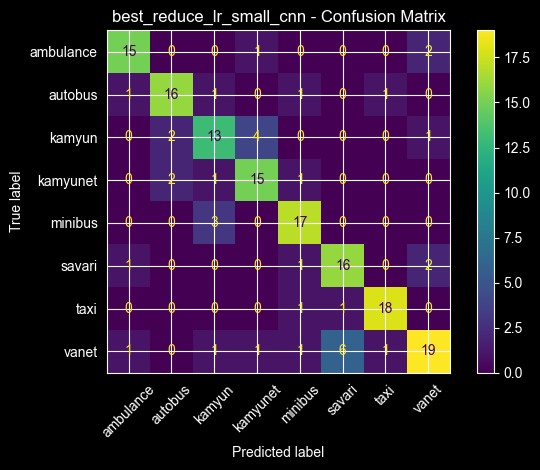

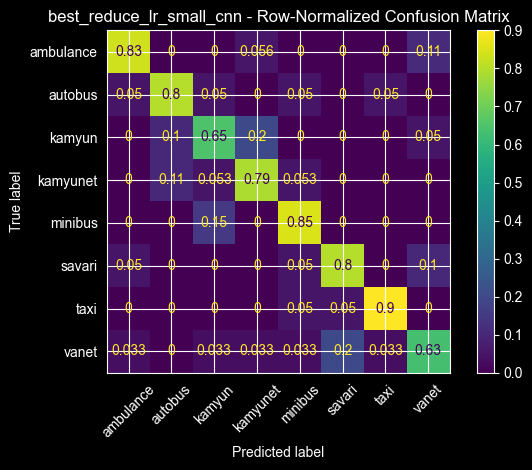

In [146]:
cm_rlr, cm_normalized_rlr = plot_confusion_matrices(
    y_true=y_true_rlr,
    y_pred=y_pred_rlr,
    classes=classes,
    experiment_name="best_reduce_lr_small_cnn",
    output_dir="../results/img"
)